# Language Modelling

- Word sequence prediction - using N-Gram model

- Document similarity measure - using cosine distance

- Context guessing - using CBOW (Continuous Bag of Words)

## N-Gram Model

An N-Gram model is useful to calculate, and predict, the probability of any given sequence of N words in a given vocabulary.

In [1]:
# Import necessary libraries
import numpy as np
import nltk
from nltk import bigrams, trigrams
from nltk.corpus import reuters
from collections import defaultdict


In [2]:
# Download necessary NLTK resources
nltk.download('reuters')
nltk.download('punkt')
nltk.download('punkt_tab')


[nltk_data] Downloading package reuters to /root/nltk_data...
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [3]:
# Tokenize the text
words = nltk.word_tokenize(' '.join(reuters.words()))
words[:10]


['ASIAN', 'EXPORTERS', 'FEAR', 'DAMAGE', 'FROM', 'U', '.', 'S', '.-', 'JAPAN']

In [4]:
print('number of words in the corpus =', len(words))
print('number of tokens (unique values) in the corpus =', len(set(words)))

number of words in the corpus = 1728932
number of tokens (unique values) in the corpus = 41516


In [5]:
# Create trigrams
tri_grams = list(trigrams(words))
tri_grams[:10]


[('ASIAN', 'EXPORTERS', 'FEAR'),
 ('EXPORTERS', 'FEAR', 'DAMAGE'),
 ('FEAR', 'DAMAGE', 'FROM'),
 ('DAMAGE', 'FROM', 'U'),
 ('FROM', 'U', '.'),
 ('U', '.', 'S'),
 ('.', 'S', '.-'),
 ('S', '.-', 'JAPAN'),
 ('.-', 'JAPAN', 'RIFT'),
 ('JAPAN', 'RIFT', 'Mounting')]

In [6]:
print('Number of possible tri-grams =',len(tri_grams))

Number of possible tri-grams = 1728930


In [7]:
# Build a trigram model
model = defaultdict(lambda: defaultdict(lambda: 0))
model

defaultdict(<function __main__.<lambda>()>, {})

In [8]:
# Count frequency of co-occurrence
for w1, w2, w3 in tri_grams:
    model[(w1,w2)][w3] += 1


In [9]:
# Example
w0='interest'
w1='and'
model[w0,w1]

defaultdict(<function __main__.<lambda>.<locals>.<lambda>()>,
            {'concern': 1,
             'corporate': 2,
             'other': 1,
             'also': 1,
             'monetary': 1,
             'exchange': 2,
             'volumes': 1,
             'repayments': 1,
             'activity': 1,
             'principal': 2,
             'negotiations': 1,
             'liquidity': 2,
             'Pratt': 1,
             'control': 1,
             'holdings': 1})

In [10]:
# Transform the counts into probabilities
for w1_w2 in model:
    total_count = float(sum(model[w1_w2].values()))
    for w3 in model[w1_w2]:
        model[w1_w2][w3] /= total_count
#print(model)

In [11]:
# Example
w0='interest'
w1='and'
model[w0,w1]

defaultdict(<function __main__.<lambda>.<locals>.<lambda>()>,
            {'concern': 0.05263157894736842,
             'corporate': 0.10526315789473684,
             'other': 0.05263157894736842,
             'also': 0.05263157894736842,
             'monetary': 0.05263157894736842,
             'exchange': 0.10526315789473684,
             'volumes': 0.05263157894736842,
             'repayments': 0.05263157894736842,
             'activity': 0.05263157894736842,
             'principal': 0.10526315789473684,
             'negotiations': 0.05263157894736842,
             'liquidity': 0.10526315789473684,
             'Pratt': 0.05263157894736842,
             'control': 0.05263157894736842,
             'holdings': 0.05263157894736842})

## Exercise 1 - Word sequence prediction using a Tri-Gram model

In [13]:
# Setup - import numpy

import numpy as np

In [20]:
# Get the user input

w1 = input('Enter the first word: ').strip()
w2 = input('Enter the second word: ').strip()

Enter the first word: stock
Enter the second word: market


In [21]:
# Set the context

context = (w1, w2)

In [22]:
# check if the context exists in the trained model

if context not in model or len(model[context]) == 0:
    print('The context is not in the trained model.')
else:
    w3_best = max(model[context], key=model[context].get)
    p_best = model[context][w3_best]
    print(f"\nMost likely next word after {context}: '{w3_best}' with probability {p_best:.6f}")



Most likely next word after ('stock', 'market'): ',' with probability 0.102041


In [26]:
# top-10 next words using argpartition
next_words = list(model[context].keys())
probabilities = np.array(list(model[context].values()), dtype=float)

k = min(10, len(next_words))

# indices of k largest probs (unordered)
topk_idx = np.argpartition(probabilities, -k)[-k:]

# sort those indices by probability descending
topk_sorted = topk_idx[np.argsort(probabilities[topk_idx])[::-1]]

print(f"\nTop {k} candidate next words for {context}:")
for i in topk_sorted:
  print(f"  {next_words[i]:<15}  {probabilities[i]:.6f}")


Top 10 candidate next words for ('stock', 'market'):
  ,                0.102041
  .                0.081633
  collapse         0.061224
  '                0.061224
  crash            0.040816
  has              0.040816
  and              0.040816
  rumors           0.040816
  analysts         0.020408
  plus             0.020408


## Exercise 2 - Document similarity measure using cosine distance

In [27]:
!pip -q install scikit-learn sentence-transformers

In [29]:
# imports
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.spatial.distance import cosine

from sentence_transformers import SentenceTransformer

In [30]:
sentence1 = input("Enter the first sentence: ")
sentence2 = input("Enter the second sentence: ")

Enter the first sentence: The growth of AI is faster than ever
Enter the second sentence: AI is growing at a very rapid pace


In [ ]:
# sentence1 = "The growth of AI is faster than ever"
# sentence2 = "AI is growing at a very rapid pace"

In [31]:
# Cosine similarity with TF-IDF

vectorizer = TfidfVectorizer()

tfidf_matrix = vectorizer.fit_transform([sentence1, sentence2])

v1 = tfidf_matrix[0].toarray()[0]
v2 = tfidf_matrix[1].toarray()[0]

cosine_distance = cosine(v1, v2)
tfidf_similarity = 1 - cosine_distance

print("TF-IDF Similarity:", tfidf_similarity)

TF-IDF Similarity: 0.1559289254870836


In [32]:
# Cosine similarity with sentence-transformer

model = SentenceTransformer("bert-base-nli-mean-tokens")

embeddings = model.encode([sentence1, sentence2])

cosine_distance_st = cosine(embeddings[0], embeddings[1])
st_similarity = 1 - cosine_distance_st

print("Sentence-Transformer Similarity:", st_similarity)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

added_tokens.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Sentence-Transformer Similarity: 0.8631337


In [33]:
print(f"TF-IDF Similarity: {tfidf_similarity:.6f}")
print(f"Sentence-Transformer Similarity: {st_similarity:.6f}")

TF-IDF Similarity: 0.155929
Sentence-Transformer Similarity: 0.863134


## Exercise 3 - Prediction of the context with CBOW

In [34]:
# Exercise 3 - CBOW: Setup (imports)
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Embedding, Lambda
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.utils import to_categorical

import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

In [35]:
# Define a toy corpus (this IS the dataset for this exercise)
corpus = [
    "The cat sat on the mat",
    "The dog ran in the park",
    "The bird sang in the tree"
]

In [36]:
# Tokenisation: create tokenizer and fit on the corpus
tokenizer = Tokenizer()
tokenizer.fit_on_texts(corpus)

# Show the mapping index -> word
print("index_word:", tokenizer.index_word)

# (Optional) show word -> index too
print("\nword_index:", tokenizer.word_index)

index_word: {1: 'the', 2: 'in', 3: 'cat', 4: 'sat', 5: 'on', 6: 'mat', 7: 'dog', 8: 'ran', 9: 'park', 10: 'bird', 11: 'sang', 12: 'tree'}

word_index: {'the': 1, 'in': 2, 'cat': 3, 'sat': 4, 'on': 5, 'mat': 6, 'dog': 7, 'ran': 8, 'park': 9, 'bird': 10, 'sang': 11, 'tree': 12}


In [37]:
# Convert each sentence to a sequence of integers
sequences = tokenizer.texts_to_sequences(corpus)

print("Integer sequences:")
for s in sequences:
    print(s)

Integer sequences:
[1, 3, 4, 5, 1, 6]
[1, 7, 8, 2, 1, 9]
[1, 10, 11, 2, 1, 12]


In [38]:
# CBOW parameters
vocab_size = len(tokenizer.word_index) + 1  # +1 because index starts at 1
embedding_size = 10
window_size = 2  # uses 2 words before + 2 words after as context

print("vocab_size:", vocab_size)
print("embedding_size:", embedding_size)
print("window_size:", window_size)

vocab_size: 13
embedding_size: 10
window_size: 2


In [39]:
# Generate context-target pairs for CBOW
contexts = []
targets = []

for seq in sequences:
    for i in range(window_size, len(seq) - window_size):
        # context = words before + words after (excluding the target itself)
        left = seq[i - window_size : i]
        right = seq[i + 1 : i + 1 + window_size]
        context = left + right

        target = seq[i]

        contexts.append(context)
        targets.append(target)

print("Contexts:", contexts)
print("Targets:", targets)

Contexts: [[1, 3, 5, 1], [3, 4, 1, 6], [1, 7, 2, 1], [7, 8, 1, 9], [1, 10, 2, 1], [10, 11, 1, 12]]
Targets: [4, 5, 8, 2, 11, 2]


In [40]:
# X: contexts as numpy array
X = np.array(contexts)

# y: targets as one-hot vectors
y = to_categorical(targets, num_classes=vocab_size)

print("X shape:", X.shape)  # expected: (#samples, 2*window_size)
print("y shape:", y.shape)  # expected: (#samples, vocab_size)

X shape: (6, 4)
y shape: (6, 13)


In [41]:
# Build CBOW model
model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=embedding_size, input_length=2 * window_size),
    Lambda(lambda x: tf.reduce_mean(x, axis=1)),   # average the context embeddings
    Dense(units=vocab_size, activation="softmax")  # predict target word
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [42]:
# Model summary
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda (Lambda)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [43]:
# Compile the model
model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])

In [44]:
# Train
history = model.fit(X, y, epochs=100, verbose=1)

Epoch 1/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 0.0000e+00 - loss: 2.5711
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 166ms/step - accuracy: 0.0000e+00 - loss: 2.5683
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step - accuracy: 0.0000e+00 - loss: 2.5656
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - accuracy: 0.0000e+00 - loss: 2.5628
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - accuracy: 0.0000e+00 - loss: 2.5600
Epoch 6/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - accuracy: 0.1667 - loss: 2.5573
Epoch 7/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step - accuracy: 0.1667 - loss: 2.5545
Epoch 8/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 150ms/step - accuracy: 0.1667 - loss: 2.5517
Epoch 9/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - accuracy: 0.1667 - loss: 2.5490
Epoch 10/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step - accuracy: 0.1667 - loss: 2.5462
Epoch 11/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step - accuracy: 0.1667 - loss: 2.5435
Epoch 12/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step 

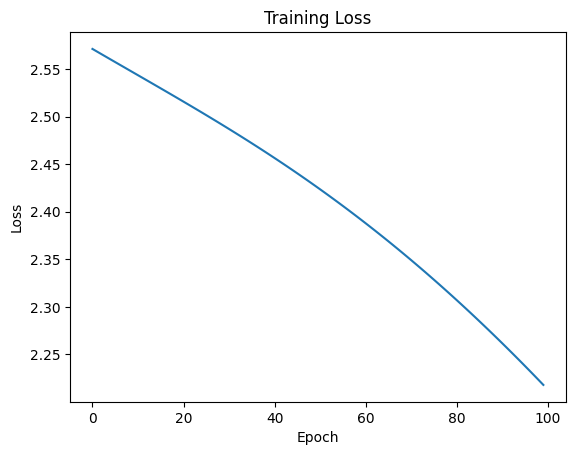

In [45]:
# Plot loss curve
plt.figure()
plt.plot(history.history["loss"])
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.show()

In [46]:
# Extract trained embedding weights
embedding_layer = model.layers[0]
embedding_weights = embedding_layer.get_weights()[0]  # shape: (vocab_size, embedding_size)

print("Embedding weights shape:", embedding_weights.shape)
print(embedding_weights)

Embedding weights shape: (13, 10)
[[ 0.0473025  -0.0491505   0.02529195 -0.03374176  0.02247587  0.00681089
   0.01295142  0.03918951 -0.00631257 -0.02412335]
 [ 0.08041073  0.07300984  0.14389353 -0.04616904 -0.04893823  0.0324181
   0.09433006  0.20631374 -0.08811674  0.2818129 ]
 [ 0.05191137 -0.0119521   0.07256901 -0.0546024   0.09325328 -0.04764925
  -0.09081542  0.18201625  0.01473917  0.04907605]
 [ 0.08073484  0.11188991  0.05014438  0.14520805 -0.08392236 -0.05124467
  -0.0252936   0.0473963  -0.00425978  0.13415894]
 [ 0.09597729  0.13698496 -0.1688098   0.10179567 -0.08372788 -0.09058949
  -0.10376834  0.08965689  0.06666533  0.13254309]
 [ 0.09362008  0.11600942  0.09979405  0.16815089  0.06274287  0.14752594
   0.06692109 -0.03925471 -0.09063998  0.12977363]
 [ 0.11989321  0.1444721  -0.14224699  0.11586363 -0.15169562 -0.1442337
  -0.10433821  0.11236964  0.13112919  0.11988688]
 [-0.14685994 -0.10763278  0.12402211 -0.09363716 -0.10331412  0.17945915
  -0.01456529  0.13

In [47]:
# PCA to reduce embeddings from 10D -> 2D
pca = PCA(n_components=2)
reduced = pca.fit_transform(embedding_weights)

print("Reduced embeddings shape:", reduced.shape)
print(reduced)

Reduced embeddings shape: (13, 2)
[[ 0.02260799  0.04773493]
 [ 0.00990828  0.16647996]
 [ 0.0866212   0.07072948]
 [ 0.21477844  0.07784831]
 [ 0.28252846 -0.13397431]
 [ 0.115908    0.27619067]
 [ 0.33847916 -0.16987078]
 [-0.24455449  0.1187604 ]
 [-0.2137525  -0.05680897]
 [-0.18683432 -0.10349052]
 [ 0.0036407  -0.12682612]
 [-0.21388313 -0.09157985]
 [-0.21544759 -0.07519311]]


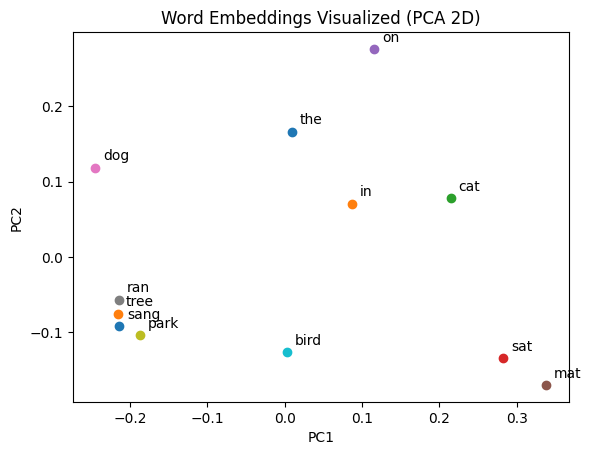

In [48]:
# Plot embeddings (skip index 0 because it's unused padding)
plt.figure()

for word, idx in tokenizer.word_index.items():
    x, y_ = reduced[idx, 0], reduced[idx, 1]
    plt.scatter(x, y_)
    plt.text(x + 0.01, y_ + 0.01, word)

plt.title("Word Embeddings Visualized (PCA 2D)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()